# The Impact of Explanatory Depth on Computing Professionals' Perceptions of AI-Generated Responses
## Quantitative Analysis - Andrea Barreto Luna

Statistical analysis and figure generation for a within-subjects mixed-methods study (N = 10, 90 observations) of how response length shapes trust, accuracy, clarity, reasoning, work reliance, and thoroughness ratings of AI-generated responses. Manuscript under review at ACM HCOMP 2026.


In [1]:
#matplotlib colour parameters

dark = "mediumvioletred"
light = "pink"
light2 = "plum"

##Data Ingest

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

##Data Cleaning // Pre Processing

In [4]:
import json

with open("data/survey_submissions_filtered.jsonl", "r") as f:
    data = [json.loads(line) for line in f]


df_outer = pd.DataFrame(data)


df_outer.iloc[0]["responses"]

exclude = {"pairResponse","pairPrompt","taskMetadata","pairMetadata","notes"}

rows = []

conversion = {"A": "Prompt A", "B": "Prompt B", "C" : "Prompt C", "M1": "Model 1", "M2": "Model 2", "M3": "Model 3","S": "Short", "L": "Long"}

#loop for cleaning data ------------------------- ------------------------- ------------------------- I manually pasted these

for _, row in df_outer.iterrows():
  participant = row["participantId"]
  count = 1
  for r in row["responses"]:
      clean_r = {}

      for key, value in r.items():
          if key not in exclude:
              clean_r[key] = value
          if key == "pairId" and len(value) != 0 :
              clean_r["prompt"] = conversion.get(value[0])
              clean_r["model"] = conversion.get(value[1:3])
              clean_r["length"] = conversion.get(value[-1])


      ## Composite Score--------------------------

      clean_r["composite_score"] = (clean_r["trust_info"]+ clean_r["appears_accurate"]+ clean_r["clear_explanation"]+ clean_r["enough_reasoning"]+ clean_r["work_reliance"]+ clean_r["thorough_explanation"]) / 6

      ## End of COmposite score---------------------
      clean_r["participant"] = participant
      clean_r["order"] = count
      count += 1
      rows.append(clean_r)

pinkyData = pd.DataFrame(rows)
#loop for cleaning data ------------------------- ------------------------- ------------------------- I manually pasted these

#Cronbaches Alpha ------------------------------------
summation = np.sum(pinkyData[["trust_info", "appears_accurate", "clear_explanation","enough_reasoning","work_reliance","thorough_explanation"]].var())
k = 6
ratings = ["trust_info","appears_accurate","clear_explanation","enough_reasoning","work_reliance","thorough_explanation"]
sigmaT = pinkyData[ratings].sum(axis=1);
sigmaTSq = sigmaT.var()
cronAlpha = (k/(k-1))*(1-(summation/sigmaTSq))

#ConBackes Alpha End ---------------------------------

##Pair ID Occurences #4 Counter Balancing---------------------

pairId = pinkyData["pairId"].value_counts()  # 5 across the board
pairIdFreq = pinkyData["pairId"].value_counts().sort_index() #

##Pair Id FInished -------------------------------


if(cronAlpha < 0.7):
  print ("Invalid for anaylsis")

print("cronAlpha: ",cronAlpha)


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

cronAlpha:  0.9000212933708557


##Corrections And Modeling

In [5]:
import statsmodels.formula.api as smf


#Report the mean, standard deviation, and sample size (n) for each of the six ratings and for the composite score,
# separately for the Short and Long conditions.
ratings = ["trust_info","appears_accurate","clear_explanation","enough_reasoning","work_reliance","thorough_explanation"]


longMean, shortMean, longSTD, shortSTD = {},{},{},{}

for r in ratings:
    longMean[r] = float(pinkyData.loc[pinkyData["length"] == "Long", r].mean())
    shortMean[r] = float(pinkyData.loc[pinkyData["length"] == "Short", r].mean())
    longSTD[r] = float(pinkyData.loc[pinkyData["length"] == "Long", r].std())
    shortSTD[r] = float(pinkyData.loc[pinkyData["length"] == "Short", r].std())
print(longMean)

# Descriptive stats update (median and interquartile range)
for r in ratings:
    long_data = pinkyData.loc[pinkyData["length"] == "Long", r]
    short_data = pinkyData.loc[pinkyData["length"] == "Short", r]

    print(f"{r}:")
    print(f"  Long:  Median={long_data.median():.2f}, IQR=[{long_data.quantile(0.25):.2f}, {long_data.quantile(0.75):.2f}]")
    print(f"  Short: Median={short_data.median():.2f}, IQR=[{short_data.quantile(0.25):.2f}, {short_data.quantile(0.75):.2f}]")



if "composite_score" not in ratings:
    ratings.append("composite_score")

#Result

#Attempt maximal random-effects structure (random slope for length) -------------------------------
print("Attempting random slope models...")
for dv in ratings:
    try:
        test_model = smf.mixedlm(
            f"{dv} ~ length + order",
            data=pinkyData,
            groups=pinkyData["participant"],
            re_formula="~length",
            vc_formula={"pairId": "0 + C(pairId)"}
        ).fit(reml=False, method="powell", maxiter=5500)
        print(f"  {dv}: random slope CONVERGED (converged={test_model.converged})")
    except Exception as e:
        print(f"  {dv}: random slope FAILED ({type(e).__name__})")

print("\nRandom slope models did not reliably converge.")
print("Falling back to random intercepts only (Matuschek et al., 2017).\n")


result = {}
for dv in ratings:
    formula = f"{dv} ~ length + order"
    model = smf.mixedlm(
        formula,
        data=pinkyData,
        groups=pinkyData["participant"],
        re_formula="~1",
        vc_formula={"pairId": "0 + C(pairId)"}
    ).fit(reml=False, method= "powell", maxiter = 5500)
    result[dv] = model



null_result = {}
for dv in ratings:

    formula = f"{dv} ~ order"
    model = smf.mixedlm(
        formula,
        data=pinkyData,
        groups=pinkyData["participant"],
        re_formula="~1",
        vc_formula={"pairId": "0 + C(pairId)"}
    ).fit(reml=False, method= "powell", maxiter = 5500)
    #print(dv, pinkyData[dv].describe())
    null_result[dv] = model
## Null Result


print("")
print("")

for r in ratings:
  print("------------",r,"------------")
  print(result[r].summary())


print("Long SD:", pinkyData.loc[pinkyData["length"] == "Long", "composite_score"].std())
print("Short SD:", pinkyData.loc[pinkyData["length"] == "Short", "composite_score"].std())

{'trust_info': 5.688888888888889, 'appears_accurate': 6.044444444444444, 'clear_explanation': 5.4, 'enough_reasoning': 6.044444444444444, 'work_reliance': 5.155555555555556, 'thorough_explanation': 5.933333333333334}
trust_info:
  Long:  Median=6.00, IQR=[5.00, 6.00]
  Short: Median=5.00, IQR=[4.00, 6.00]
appears_accurate:
  Long:  Median=6.00, IQR=[6.00, 7.00]
  Short: Median=5.00, IQR=[4.00, 6.00]
clear_explanation:
  Long:  Median=6.00, IQR=[5.00, 6.00]
  Short: Median=5.00, IQR=[4.00, 6.00]
enough_reasoning:
  Long:  Median=6.00, IQR=[6.00, 7.00]
  Short: Median=3.00, IQR=[2.00, 4.00]
work_reliance:
  Long:  Median=6.00, IQR=[3.00, 6.00]
  Short: Median=3.00, IQR=[2.00, 5.00]
thorough_explanation:
  Long:  Median=6.00, IQR=[5.00, 7.00]
  Short: Median=3.00, IQR=[2.00, 4.00]
Attempting random slope models...
  trust_info: random slope CONVERGED (converged=True)
  appears_accurate: random slope CONVERGED (converged=True)
  clear_explanation: random slope CONVERGED (converged=True)
  

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  thorough_explanation: random slope CONVERGED (converged=True)
  composite_score: random slope CONVERGED (converged=True)

Random slope models did not reliably converge.
Falling back to random intercepts only (Matuschek et al., 2017).



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)




------------ trust_info ------------
          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: trust_info
No. Observations:   90      Method:             ML        
No. Groups:         10      Scale:              0.6218    
Min. group size:    9       Log-Likelihood:     -141.4510 
Max. group size:    9       Converged:          Yes       
Mean group size:    9.0                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        5.777    0.331 17.450 0.000  5.129  6.426
length[T.Short] -1.057    0.242 -4.367 0.000 -1.532 -0.583
order           -0.012    0.046 -0.260 0.795 -0.103  0.079
Group Var        0.175                                    
pairId Var       0.617                                    

------------ appears_accurate ------------
            Mixed Linear Model Regression R

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#Likelihood ratio tests, holm-bonferroni alpha, and R^2


In [6]:
from scipy.stats import chi2

#LRT: full vs null models -------------------------------
lrtRows = []
alpha = 0.05

for dv in ratings:
    full = result[dv]
    null = null_result[dv]

    lrStat = max(0, 2 * (full.llf - null.llf))
    dfDiff = len(full.fe_params) - len(null.fe_params)
    pValue = chi2.sf(lrStat, dfDiff)

    # Nakagawa R²
    fixed_pred = full.model.exog @ np.array(full.fe_params)
    var_fixed = np.var(fixed_pred)
    var_participant = full.cov_re.iloc[0, 0]
    var_pairId = full.vcomp[0]
    var_residual = full.scale
    var_total = var_fixed + var_participant + var_pairId + var_residual
    marginalR2 = var_fixed / var_total
    conditionalR2 = (var_fixed + var_participant + var_pairId) / var_total

    # Cohen's d (Westfall, Kenny, & Judd, 2014)
    length_term = [name for name in full.fe_params.index if name.startswith("length[")][0]
    beta = full.fe_params[length_term]
    total_sd = np.sqrt(var_participant + var_pairId + var_residual)
    cohens_d = beta / total_sd

    lrtRows.append({
        "DV": dv,
        "chi2": round(lrStat, 4),
        "df": dfDiff,
        "pValue": round(pValue, 4),
        "marginalR2": round(marginalR2, 4),
        "conditionalR2": round(conditionalR2, 4),
        "cohens_d": round(cohens_d, 4),
    })

lrtTable = pd.DataFrame(lrtRows)

#Holm-Bonferroni correction -------------------------------
# Separate individual measures from composite (composite is a single planned test)
individual = lrtTable[lrtTable["DV"] != "composite_score"].copy()
composite  = lrtTable[lrtTable["DV"] == "composite_score"].copy()

# Sort individual measures by p-value (smallest first)
individual = individual.sort_values("pValue").reset_index(drop=True)
m = len(individual)  # 6 tests

# Holm procedure: kth smallest p compared to alpha / (m - k)
holm_sig = []
holm_alpha = []
rejected = True  # track whether we're still rejecting
for k in range(m):
    threshold = alpha / (m - k)
    holm_alpha.append(round(threshold, 4))
    if rejected and individual.loc[k, "pValue"] <= threshold:
        holm_sig.append(True)
    else:
        rejected = False  # once one fails, all remaining fail
        holm_sig.append(False)

individual["alphaUsed"] = holm_alpha
individual["significance"] = holm_sig

# Composite: single planned test, uncorrected alpha
composite["alphaUsed"] = alpha
composite["significance"] = composite["pValue"] < alpha

# Recombine and print
lrtTable = pd.concat([individual, composite], ignore_index=True)
print(lrtTable.to_string(index=False))


                  DV    chi2  df  pValue  marginalR2  conditionalR2  cohens_d  alphaUsed  significance
          trust_info 16.8557   1  0.0000      0.1625         0.6317   -0.8889     0.0083          True
    appears_accurate 18.3169   1  0.0000      0.1630         0.6653   -0.8900     0.0100          True
    enough_reasoning 77.9392   1  0.0000      0.5722         0.8142   -2.3160     0.0125          True
       work_reliance 32.7488   1  0.0000      0.2628         0.7419   -1.1707     0.0167          True
thorough_explanation 78.2267   1  0.0000      0.5997         0.8069   -2.3839     0.0250          True
   clear_explanation  4.5577   1  0.0328      0.0524         0.6013   -0.4366     0.0500          True
     composite_score 50.7279   1  0.0000      0.4095         0.7621   -1.6597     0.0500          True


#vpc

In [7]:
#Variance Partitioning -------------------------------
vpcRows = []

for dv in ratings:
    model = result[dv]

    groupVar = model.cov_re.iloc[0, 0]
    pairVar = model.vcomp[0]
    residVar = model.scale

    totalVar = groupVar + pairVar + residVar

    participantVpc = groupVar / totalVar
    stimulusVpc= pairVar / totalVar
    residualVpc = residVar / totalVar

    vpcRows.append({
        "DV": dv,
        "groupVar": round(groupVar, 6),
        "pairVar": round(pairVar, 6),
        "residVar": round(residVar, 6),
        "participantVpc": round(participantVpc, 6),
        "stimulusVpc": round(stimulusVpc, 6),
        "residualVpc": round(residualVpc, 6)
    })

vpcTable = pd.DataFrame(vpcRows)
print(vpcTable.to_string(index=False))

                  DV  groupVar  pairVar  residVar  participantVpc  stimulusVpc  residualVpc
          trust_info  0.175258 0.617081  0.621837        0.123930     0.436354     0.439717
    appears_accurate  0.385633 0.754885  0.760137        0.202895     0.397171     0.399934
   clear_explanation  0.305900 0.815466  0.814378        0.158027     0.421268     0.420705
    enough_reasoning  0.184623 0.596094  0.599705        0.133744     0.431820     0.434436
       work_reliance  0.770494 0.899933  0.900005        0.299753     0.350110     0.350138
thorough_explanation  0.067610 0.676674  0.693907        0.047010     0.470504     0.482486
     composite_score  0.213027 0.434477  0.436829        0.196459     0.400686     0.402855


In [8]:
#Null model VPCs (LEVEL checklist) -------------------------------
print("\nNull Model VPCs (baseline, no fixed effects of interest):")
for dv in ratings:
    null = null_result[dv]

    null_participant = null.cov_re.iloc[0, 0]
    null_pairId = null.vcomp[0]
    null_residual = null.scale
    null_total = null_participant + null_pairId + null_residual

    print(f"  {dv}: participant={null_participant/null_total:.3f}, "
          f"stimulus={null_pairId/null_total:.3f}, "
          f"residual={null_residual/null_total:.3f}")


Null Model VPCs (baseline, no fixed effects of interest):
  trust_info: participant=0.068, stimulus=0.466, residual=0.467
  appears_accurate: participant=0.134, stimulus=0.432, residual=0.434
  clear_explanation: participant=0.130, stimulus=0.434, residual=0.437
  enough_reasoning: participant=0.000, stimulus=1.000, residual=0.000
  work_reliance: participant=0.183, stimulus=0.409, residual=0.408
  thorough_explanation: participant=0.000, stimulus=1.000, residual=0.000
  composite_score: participant=0.053, stimulus=0.467, residual=0.480


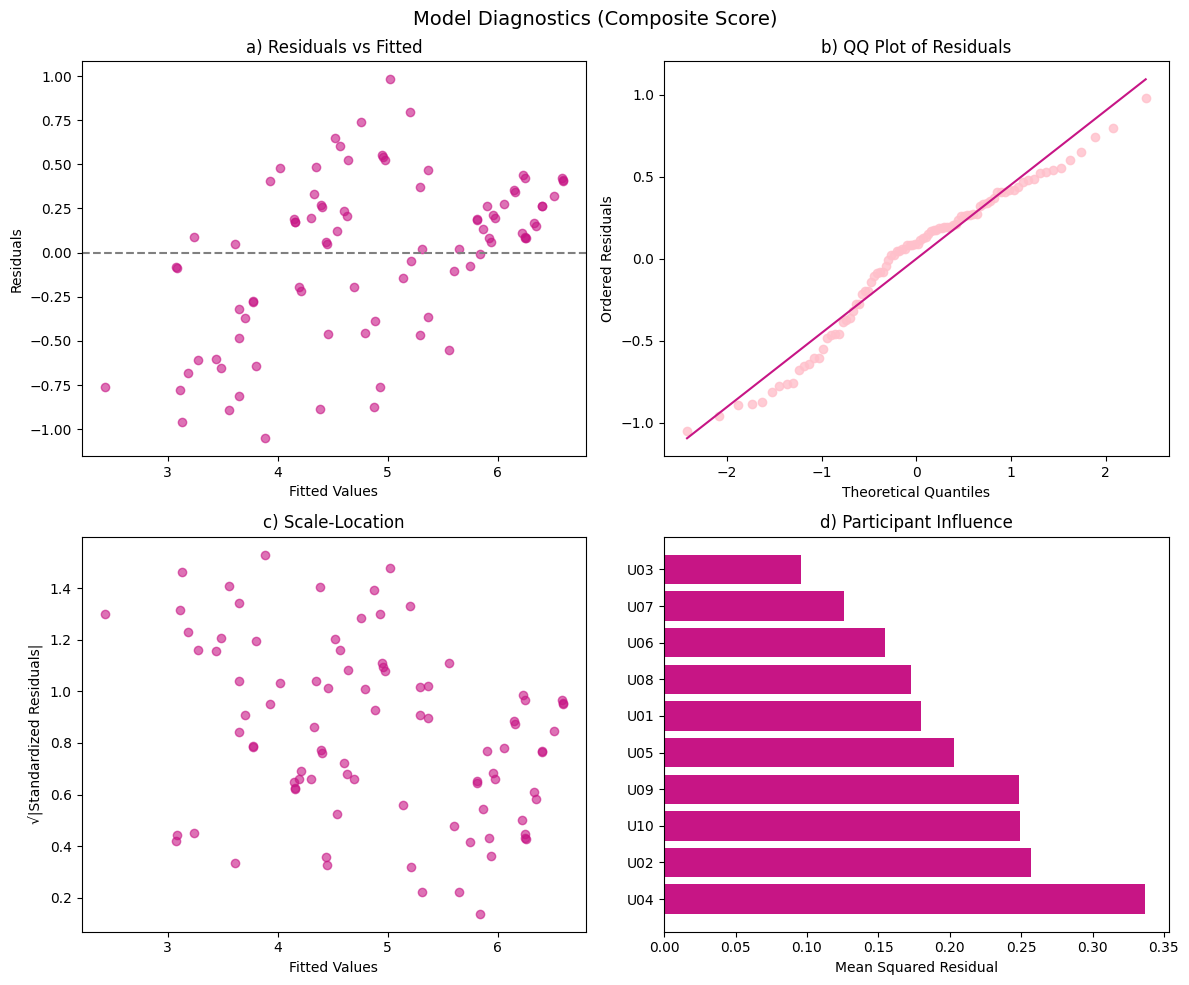

In [11]:
#Model Diagnostics (Appendix) -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Model Diagnostics (Composite Score)", fontsize=14)

model = result["composite_score"]
residuals = model.resid
fitted = model.fittedvalues

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.6, color=dark)
axes[0, 0].axhline(0, color="grey", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("a) Residuals vs Fitted")

# 2. QQ Plot of Residuals
from scipy import stats

qq = stats.probplot(residuals, dist="norm", plot=None)
theoretical = qq[0][0]
ordered = qq[0][1]
slope = qq[1][0]
intercept = qq[1][1]

axes[0, 1].scatter(theoretical, ordered, alpha=0.8, color=light)
x = np.linspace(min(theoretical), max(theoretical), 100)
axes[0, 1].plot(x, slope * x + intercept, color=dark)

axes[0, 1].set_title("b) QQ Plot of Residuals")
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Ordered Residuals")

# 3. Scale Location (sqrt of standardized residuals vs fitted)
std_resid = residuals / np.std(residuals)
axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.6, color=dark)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")
axes[1, 0].set_title("c) Scale-Location")

# 4. Participant Influence (mean absolute residual per participant)
pinkyData["resid"] = residuals
participant_influence = pinkyData.groupby("participant")["resid"].apply(
    lambda x: np.mean(x**2)
).sort_values(ascending=False)
axes[1, 1].barh(participant_influence.index, participant_influence.values, color=dark)
axes[1, 1].set_xlabel("Mean Squared Residual")
axes[1, 1].set_title("d) Participant Influence")
pinkyData.drop(columns=["resid"], inplace=True)

plt.tight_layout()
plt.savefig("diagnostics.svg" , bbox_inches="tight", pad_inches=0.02)
plt.show()


# Pretty Graphs uwu owo

## FIGURES:

1.  Grouped bar chart (all 6 measures (x) + significance markers ( y )  )

2. Spaghetti plot (composite ( y) , per participant) (on x you have short as one dot on the left, and long as one dot on the right)

3. Forest plot (effect sizes with CIs) (significance markers ( y ), beta (x)

4. Spaghetti plots (all 6 measures, so 6 plots) (Rating on the y axis, short & long on the x axis)

5. Box + strip plot (composite) (composite rating on the y axis, short/long on y axis)

---

### Figure 1 : Grouped bar chart

- Bar heights (means) = raw data
- Error bars (standard errors) = raw data
- Significance stars = LMM, from the LRT p-values after the [Holm (1979)](https://www.jstor.org/stable/4615733) sequential correction

### Figure 2 : Spaghetti plot (composite)

- Gray lines (each participant's Short mean to Long mean) = raw data
- Bold black line (group mean) = raw data
- Everything is raw data, no LMM involved in this figure at all

### Figure 3 : Forest plot

- Horizontal bars (beta coefficients) = LMM
- Error bars (95% CIs, calculated from beta +/- 1.96 x SE) = LMM
- Bar colors (green if significant, gray if not) = LMM, same Holm corrected p-values as fig 1
- This is the only figure that is entirely from LMM output
- effect sizes standardized following [Westfall, Kenny & Judd (2014)](https://doi.org/10.1037/xge0000014), beta over the total random effects SD

### Figure 4 : Spaghetti plots (all 6 measures)

- Gray lines (per participant) = raw data
- Bold black lines (group means) = raw data
- P-value annotations on each panel = LMM, tested with LRTs since those hold up better than Wald z with only 10 participants ([Wiley & Rapp, 2019](https://doi.org/10.1080/02687038.2018.1454884))
- Mostly raw data, just the p-value text comes from LMM

### Figure 5 : Box + strip plot (composite)

- Boxes (quartiles, median) = raw data
- Individual dots = raw data
- Everything is raw data, no LMM involved

---

modeling notes: tried the maximal random effects structure first per [Barr et al. (2013)](https://doi.org/10.1016/j.jml.2012.11.001), slopes wouldn't converge so I dropped to random intercepts only, which [Matuschek et al. (2017)](https://doi.org/10.1016/j.jml.2017.01.001) says is fine when the data can't support the complexity. R2 for the models is the marginal/conditional split from [Nakagawa & Schielzeth (2013)](https://doi.org/10.1111/j.2041-210x.2012.00261.x). The null model VPC printout is there because the [LEVEL guidelines](https://doi.org/10.1186/s12874-019-0876-8) want variance decomposition reported from both the null and full models.

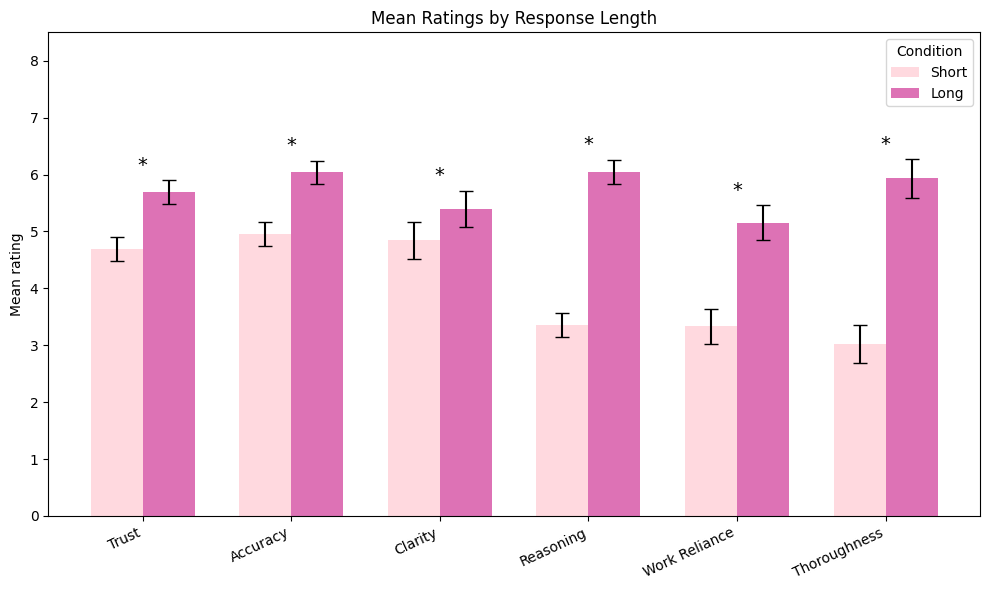

In [12]:
import matplotlib.pyplot as plt
import numpy as np


ratings = [
    "trust_info",
    "appears_accurate",
    "clear_explanation",
    "enough_reasoning",
    "work_reliance",
    "thorough_explanation"
]

labels = {
    "trust_info": "Trust",
    "appears_accurate": "Accuracy",
    "clear_explanation": "Clarity",
    "enough_reasoning": "Reasoning",
    "work_reliance": "Work Reliance",
    "thorough_explanation": "Thoroughness"
}

#Within subject error bars (Morey) -------------------------------
K = 2
morey_correction = np.sqrt(K / (K - 1))

longErr_ws, shortErr_ws = {}, {}

for r in ratings:
    # 1. Aggregate to participant × condition means FIRST
    agg = pinkyData.groupby(["participant", "length"])[r].mean().unstack()

    # 2. Compute each participant's grand mean (across Short & Long)
    subj_grand = agg.mean(axis=1)

    # 3. Overall grand mean
    grand_mean = agg.values.mean()

    # 4. Normalize: remove between-subject variance
    agg_norm = agg.sub(subj_grand, axis=0) + grand_mean

    # 5. Compute SE on normalized aggregated scores, apply Morey correction
    longErr_ws[r]  = float(agg_norm["Long"].sem() * morey_correction)
    shortErr_ws[r] = float(agg_norm["Short"].sem() * morey_correction)
#-------------------------------------------------


#

longV = [longMean[r] for r in ratings]
shortV = [shortMean[r] for r in ratings]

#longErr = [longSTD[r] for r in ratings]
#shortErr = [shortSTD[r] for r in ratings]

longErr = [longErr_ws[r] for r in ratings]
shortErr = [shortErr_ws[r] for r in ratings]

#Bar Plot -------------------------------
x = np.arange(len(ratings))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width/2,
    shortV,
    width,
    label="Short",
    color=light,
    yerr=shortErr,
    capsize=5,
    alpha=0.6,
)

ax.bar(
    x + width/2,
    longV,
    width,
    label="Long",
    color=dark,
    yerr=longErr,
    capsize=5,
    alpha=0.6,
)
ratings2 =  ["trust_info","appears_accurate","clear_explanation","enough_reasoning","thorough_explanation","work_reliance"]


for i, r in enumerate(ratings2):
    sigRow = lrtTable.loc[lrtTable["DV"] == r, "significance"]

    if len(sigRow) > 0 and bool(sigRow.iloc[0]):
        y = max(shortV[i] + shortErr[i], longV[i] + longErr[i]) + 0.03
        h = 0.06

       # ax.plot(
       #     [x[i] - width/2, x[i] - width/2, x[i] + width/2, x[i] + width/2],
       #     [y, y + h, y + h, y],
       #     color="black",
       #     linewidth=1.2
       # )

        ax.text(
            x[i],
            y + h + 0.01,
            "*",
            ha="center",
            va="bottom",
            fontsize=14
        )

ax.set_ylabel("Mean rating")
ax.set_title("Mean Ratings by Response Length")
ax.set_xticks(x)
ax.set_xticklabels([labels[r] for r in ratings], rotation=25, ha="right")
plt.legend(title="Condition")

plt.tight_layout()
plt.ylim(0, 8.5)
plt.savefig("barGraph.svg" , bbox_inches="tight", pad_inches=0.02)
plt.show()

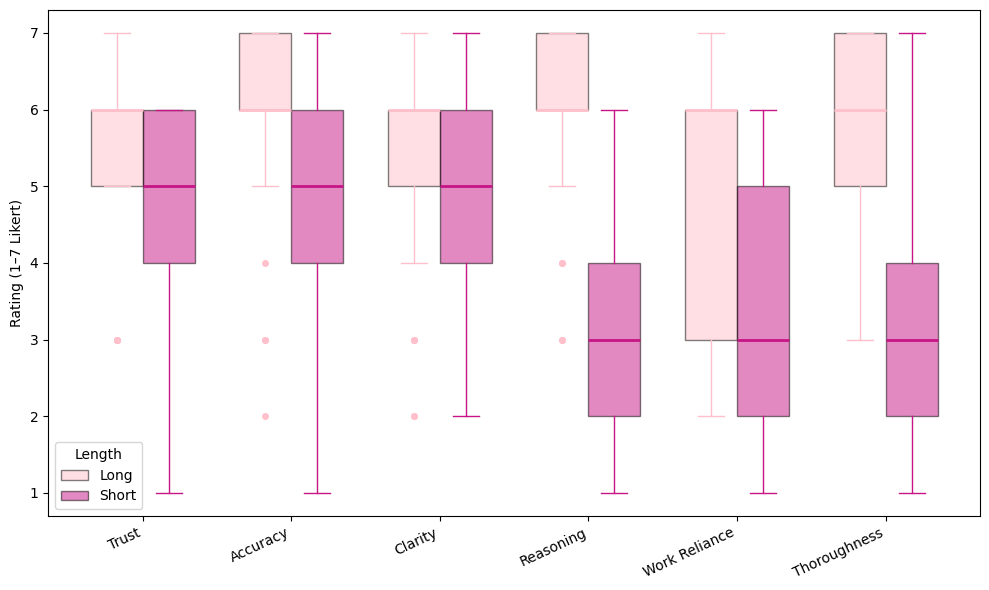

In [13]:
#Grouped Boxplots (Long vs Short) -------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

positions = range(len(ratings))
width = 0.35

flier_long = dict(marker='o', markerfacecolor=light, markeredgecolor=light, markersize=4)
flier_short = dict(marker='o', markerfacecolor=dark, markeredgecolor=dark, markersize=4)
long_data = [pinkyData.loc[pinkyData["length"] == "Long", r].dropna().values for r in ratings]
short_data = [pinkyData.loc[pinkyData["length"] == "Short", r].dropna().values for r in ratings]

bp_long = ax.boxplot(long_data, positions=[p - width/2 for p in positions],
                     widths=width, patch_artist=True, manage_ticks=False, flierprops=flier_long)
bp_short = ax.boxplot(short_data, positions=[p + width/2 for p in positions],
                      widths=width, patch_artist=True, manage_ticks=False, flierprops=flier_short)

for box in bp_long["boxes"]:
    box.set(facecolor=light, alpha=0.5)
for med in bp_long["medians"]:
    med.set(color=light, linewidth=2)
for elem in ["whiskers", "caps"]:
    for line in bp_long[elem]:
        line.set(color=light)

for box in bp_short["boxes"]:
    box.set(facecolor=dark, alpha=0.5)
for med in bp_short["medians"]:
    med.set(color=dark, linewidth=2)
for elem in ["whiskers", "caps"]:
    for line in bp_short[elem]:
        line.set(color=dark)

ax.set_xticks(list(positions))
ax.set_xticklabels([labels[r] for r in ratings], rotation=25, ha="right")
ax.set_ylabel("Rating (1–7 Likert)")
ax.legend([bp_long["boxes"][0], bp_short["boxes"][0]], ["Long", "Short"], title="Length")
plt.tight_layout()
plt.savefig("box.svg" , bbox_inches="tight", pad_inches=0.02)
plt.show()

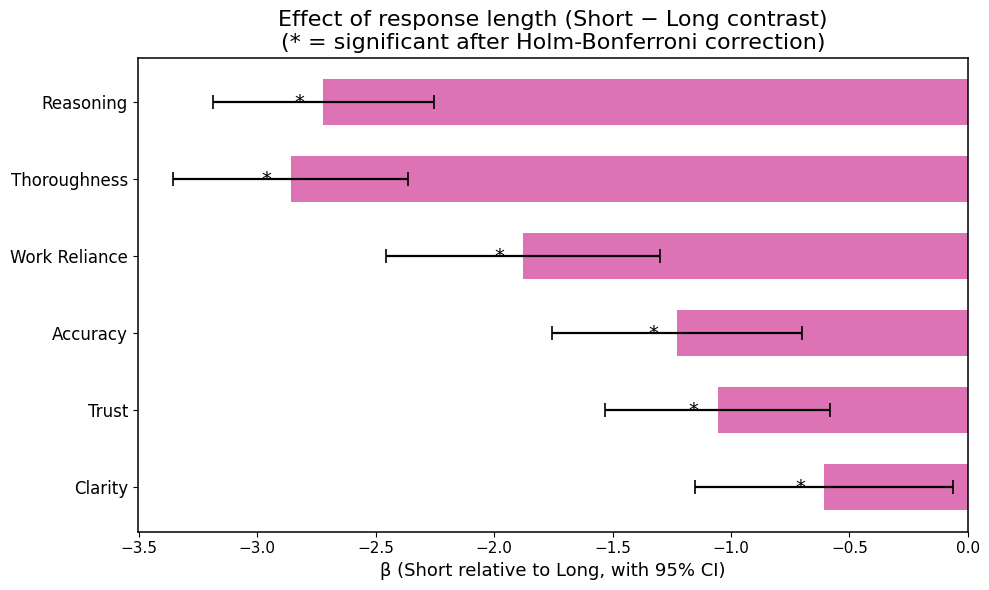

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

label_map = {
    "trust_info": "Trust",
    "appears_accurate": "Accuracy",
    "clear_explanation": "Clarity",
    "enough_reasoning": "Reasoning",
    "work_reliance": "Work Reliance",
    "thorough_explanation": "Thoroughness",
    "composite_score": "Composite Score"
}


#Pull length betas from each model -------------------------------
forestRows = []

for dv in ratings:
    model = result[dv]

    length_term = None
    for name in model.fe_params.index:
        if name.startswith("length["):
            length_term = name
            break

    if length_term is None:
        continue

    est = model.fe_params[length_term]
    ci = model.conf_int().loc[length_term]
    pval = model.pvalues[length_term]

    forestRows.append({
        "dv": dv,
        "label": label_map.get(dv, dv),
        "beta": est,
        "lower": ci[0],
        "upper": ci[1],
        "p": pval
    })

forestDF = pd.DataFrame(forestRows)

# drop composite so the plot shows the six individual measures
forestDF = forestDF[forestDF["dv"] != "composite_score"].copy()

# sort by effect size
forestDF = forestDF.sort_values("beta").reset_index(drop=True)

# Bonferroni threshold
alpha = 0.05
bonf = alpha / len(forestDF)

# Apply Holm-Bonferroni to forest plot significance
forestDF = forestDF.sort_values("p").reset_index(drop=True)
m_forest = len(forestDF)
forest_sig = []
forest_rejected = True
for k in range(m_forest):
    threshold = 0.05 / (m_forest - k)
    if forest_rejected and forestDF.loc[k, "p"] <= threshold:
        forest_sig.append(True)
    else:
        forest_rejected = False
        forest_sig.append(False)
forestDF["sig"] = forest_sig

# bye bye previous bonferroni forestDF["sig"] = forestDF["p"] < bonf

# positions
y = np.arange(len(forestDF))

fig, ax = plt.subplots(figsize=(10, 6))

# draw translucent bars from beta to 0
for i, row in forestDF.iterrows():
    left = min(row["beta"], 0)
    width = abs(row["beta"] - 0)

    fill_color = dark if row["sig"] else light

    ax.barh(
        y=i,
        width=width,
        left=left,
        height=0.6,
        color=fill_color,
        edgecolor="none",
        alpha=0.6
    )

# draw 95% CI as black horizontal error bars
xerr = np.vstack([
    forestDF["beta"] - forestDF["lower"],
    forestDF["upper"] - forestDF["beta"]
])

ax.errorbar(
    forestDF["beta"],
    y,
    xerr=xerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.6,
    capsize=5,
    capthick=1.2
)

# optional significance marker
for i, row in forestDF.iterrows():
    if row["sig"]:
        ax.text(
            row["beta"] - 0.08,
            i,
            "*",
            va="center",
            ha="right",
            fontsize=14,
        )

ax.set_yticks(y)
ax.set_yticklabels(forestDF["label"], fontsize=12)

ax.set_xlabel("β (Short relative to Long, with 95% CI)", fontsize=13)
ax.set_title(
    "Effect of response length (Short − Long contrast)\n"
    "(* = significant after Holm-Bonferroni correction)",
    fontsize=16
)

# make it look like your example
ax.set_xlim(min(forestDF["lower"].min() - 0.15, -3.5), 0)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("forest.svg" , bbox_inches="tight", pad_inches=0.02)
plt.show()

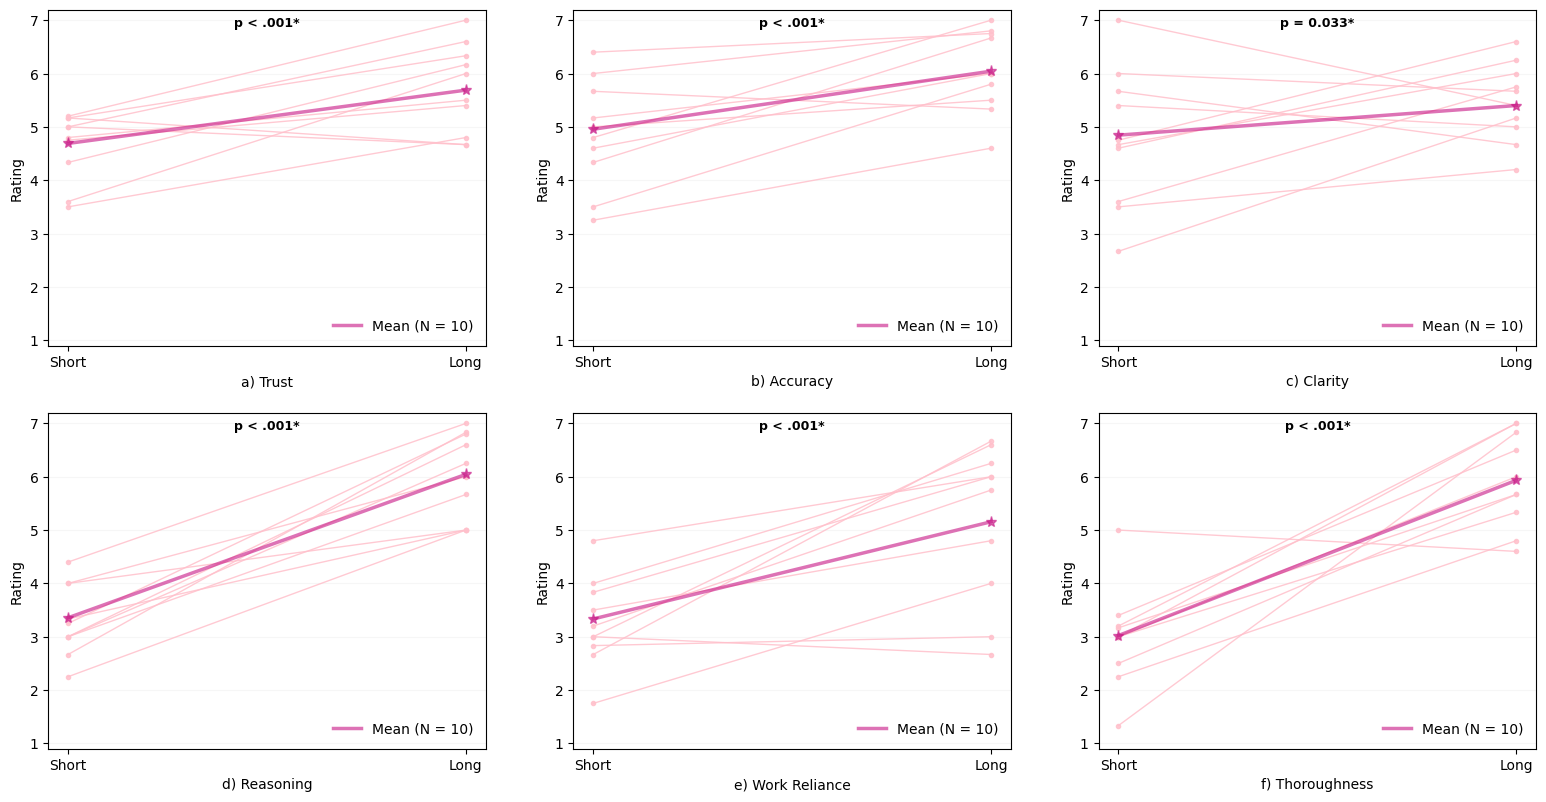

In [15]:
nice_names = {"trust_info": "Trust","appears_accurate": "Accuracy","clear_explanation": "Clarity","enough_reasoning": "Reasoning","work_reliance": "Work Reliance","thorough_explanation": "Thoroughness","composite_score": "Composite Score"}

#Spaghetti Grid (one panel per measure) -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(19.2, 9.6))
axes = axes.flatten()
plot_i = 0

for field in ratings:
  if field == "composite_score":
    continue

  ax = axes[plot_i]
  plot_i += 1


  label = chr(ord('a') + plot_i - 1)
  #print(label)

  for a in pinkyData["participant"].unique():
    targ = pinkyData[pinkyData["participant"] == a]
    s = targ[targ["length"] == "Short"][field].mean()
    l = targ[targ["length"] == "Long"][field].mean()
    field.replace("_", " ").title()
    ax.plot(["Short", "Long"], [s, l], marker="o", color=light, alpha=0.85, linewidth=1,markersize=3)

  sMean = pinkyData[pinkyData["length"] == "Short"][field].mean()
  lMean = pinkyData[pinkyData["length"] == "Long"][field].mean()
  n = pinkyData["participant"].nunique()
  ax.plot(["Short", "Long"], [sMean, lMean], marker="*", color=dark, linewidth=2.5, markersize=8,alpha=0.6,label="Mean (N = %d)" % n )

  row = lrtTable[lrtTable["DV"] == field].iloc[0]
  p = row["pValue"]
  sig = row["significance"]

  if p < .001:
      p_text = "p < .001"
  else:
      p_text = "p = %.3f" % p

  if sig:
      p_text += "*"

  ax.text(0.5, 0.95, p_text, ha="center", fontweight="bold" if sig else "normal", fontsize=9, transform=ax.transAxes)

  #ax.spines["top"].set_visible(False)
  #ax.spines["right"].set_visible(False)
  ax.set_yticks([1, 2, 3, 4, 5, 6, 7])
  ax.set_ylabel("Rating")
  ax.set_xlabel(label+") "+nice_names[field])
  ax.set_ylim(0.9, 7.2)
  legend = ax.legend(loc="lower right", frameon=False)
  legend.legend_handles[0].set_marker("")
  #plt.legend()
  ax.grid(axis="y", alpha=0.1, linestyle="-")


plt.savefig("spag.svg", bbox_inches="tight", pad_inches=0.02)
  #plt.show()

['U08' 'U06' 'U01' 'U02' 'U10' 'U07' 'U04' 'U03' 'U05' 'U09']


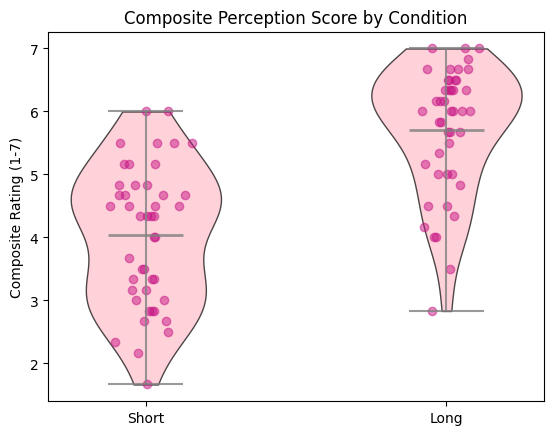

In [16]:
#Violin + Scatter (composite) -------------------------------
print(pinkyData["participant"].unique())

short = pinkyData[pinkyData["length"] == "Short"]["composite_score"]
long  = pinkyData[pinkyData["length"] == "Long"]["composite_score"]


np.random.seed(827127050)

plt.figure()
vp = plt.violinplot([short, long], showmeans=True)

for body in vp['bodies']:
    body.set_facecolor(light)
    body.set_edgecolor('black')
    body.set_alpha(0.7)


vp['cmeans'].set_color('grey')
vp['cmeans'].set_linewidth(2)

vp['cbars'].set_color('grey')
vp['cmaxes'].set_color('grey')
vp['cmins'].set_color('grey')

vp['cmeans'].set_alpha(0.8)

vp['cbars'].set_alpha(0.8)
vp['cmaxes'].set_alpha(0.8)
vp['cmins'].set_alpha(0.8)


plt.xticks([1, 2], ["Short", "Long"])

#Scatter
#plt.figure()
for a, data in enumerate([short, long]):
    x = np.random.normal(a + 1, 0.05, size=len(data))
    plt.scatter(x, data, alpha=0.5, color=dark)

plt.xticks([1, 2], ["Short", "Long"])
plt.ylabel("Composite Rating (1-7)")
plt.title("Composite Perception Score by Condition")
plt.savefig("Violin.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()